# Exploratory Data Analysis
Questions:
1. What the data looks like -- shape, types, Nan values
2. Target variable distribution
3. Which features separate the two classes (Liberal vs. Non-Liberal) the most
4. Which features are redundant (multicollinearity)
5. Which features to choose for modeling
6. MOST IMPORTANT: which optimization algorithms and kernels to try

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))

from preprocessing import (
    clean_ridings_data,
    load_features_target,
    load_ridings_data,
    BINARY_TARGET_COLUMN,
    FEATURE_COLUMNS,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

#load data
raw_df = load_ridings_data()
df = clean_ridings_data(raw_df)
X, y = load_features_target()

# is liberal col created automatically by clean_ridings data()

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 342
Columns: 23


---
## 1 -- Dataset Shape & Data Types



In [2]:
display(df.dtypes.to_frame("dtype"))

,dtype
Unnamed: 0,int64
riding,str
Ave_Age_All,float64
Ave_Age_Male,float64
Ave_Age_Female,float64
bike_rate,float64
pop,int64
NoPostsecondary_all,float64
NoPostsecondary_male,float64
NoPostsecondary_female,float64


In [3]:
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))

,missing_values
Unnamed: 0,0
riding,0
Ave_Age_All,0
Ave_Age_Male,0
Ave_Age_Female,0
bike_rate,0
pop,0
NoPostsecondary_all,0
NoPostsecondary_male,0
NoPostsecondary_female,0


In [4]:
summary = {
    "unique_ridings": df["riding"].nunique(),
    "duplicate_riding_names": df["riding"].duplicated().sum(),
    "missing_target_rows": df["Political Affiliation"].isna().sum(),
}

pd.Series(summary, name="count")

unique_ridings            342
duplicate_riding_names      0
missing_target_rows         0
Name: count, dtype: int64

After dropping the 1 row that has a missing political affiliation, the data is all cleaned.

---
## 2 -- Target Distribution


In [5]:
print("All parties:")
print(df["Political Affiliation"].value_counts())
print()
print("Binary target (Liberal = 1, Non-Liberal = 0):")
print(df["is_liberal"].value_counts())

All parties:
Political Affiliation
Liberal           170
Conservative      142
Bloc Québécois     22
NDP                 7
Green Party         1
Name: count, dtype: int64

Binary target (Liberal = 1, Non-Liberal = 0):
is_liberal
0    172
1    170
Name: count, dtype: int64


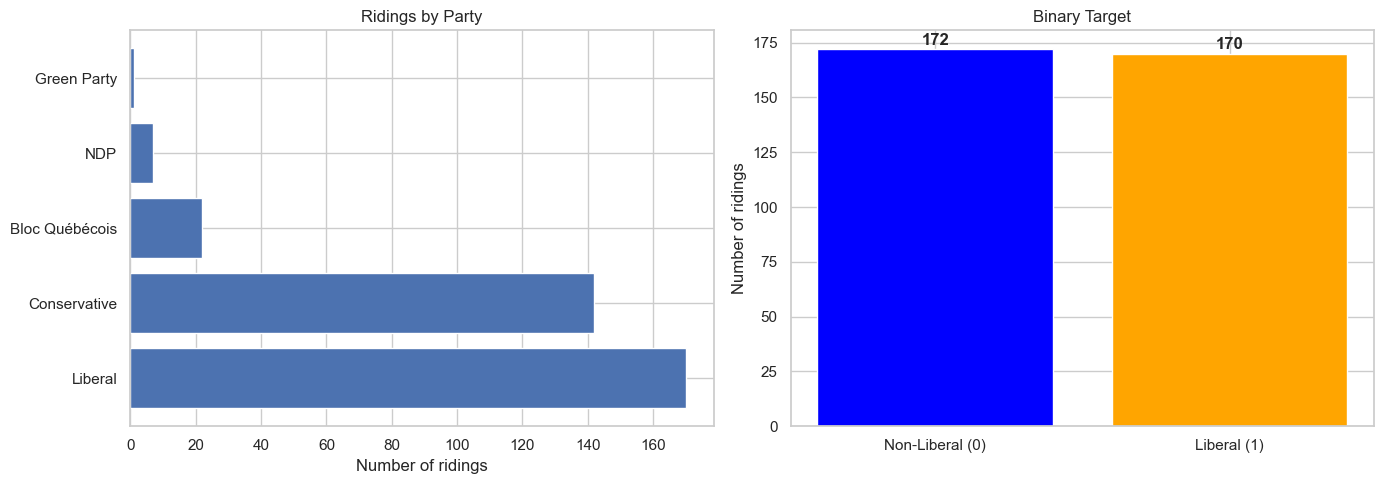

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: all parties
party_counts = df["Political Affiliation"].value_counts()
axes[0].barh(party_counts.index, party_counts.values)
axes[0].set_title("Ridings by Party")
axes[0].set_xlabel("Number of ridings")

# right: binary target
bc = df["is_liberal"].value_counts().sort_index()
bars = axes[1].bar(["Non-Liberal (0)", "Liberal (1)"], bc.values,
                   color=["blue", "orange"])
axes[1].set_title("Binary Target")
axes[1].set_ylabel("Number of ridings")
for bar, val in zip(bars, bc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2,
                str(val), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### GOOD NEWS: The binary split is almost perfect.
You have no idea how lucky we are truly

---
## 3 -- Province vs Party

In [10]:
ct = pd.crosstab(df["Province / Territory"], df["is_liberal"])
ct.columns = ["Non-Liberal", "Liberal"]
ct["Liberal %"] = (ct["Liberal"] / ct.sum(axis=1) * 100).round(1)
ct = ct.sort_values("Liberal %", ascending=False)
display(ct)

,Non-Liberal,Liberal,Liberal %
Province / Territory,,,
Northwest Territories,0,1,100.0
Prince Edward Island,0,4,100.0
Yukon,0,1,100.0
Nova Scotia,0,11,100.0
New Brunswick,4,6,60.0
Ontario,51,70,57.9
Newfoundland and Labrador,3,4,57.1
Quebec,34,44,56.4
British Columbia,23,20,46.5


Please note there are some strong geographic patterns:
- Atlantic part is almost entirely liberal
- Saskatchewan almost entirely non-liberal


I discarded geography for now, since it has 13 levels -- +13 to dimensionality.
But we may need to run both models -- with geographic features and without

---
## 4 -- Numeric Features Summary

In [12]:
numeric_columns = [
    col for col in df.select_dtypes(include=["number"]).columns
    if col not in ["Unnamed: 0", "is_liberal"]
]
print(f"{len(numeric_columns)} numeric features: {numeric_columns}")

16 numeric features: ['Ave_Age_All', 'Ave_Age_Male', 'Ave_Age_Female', 'bike_rate', 'pop', 'NoPostsecondary_all', 'NoPostsecondary_male', 'NoPostsecondary_female', 'french', 'HouseNeed', 'income_all', 'income_male', 'income_female', 'unemploy_all', 'unemploy_male', 'unemploy_female']


In [13]:
df[numeric_columns].describe().round(2)

,Ave_Age_All,Ave_Age_Male,Ave_Age_Female,bike_rate,pop,NoPostsecondary_all,NoPostsecondary_male,NoPostsecondary_female,french,HouseNeed,income_all,income_male,income_female,unemploy_all,unemploy_male,unemploy_female
count,342.00,342.00,342.00,342.00,342.00,342.00,342.00,342.00,342.00,342.00,342.00,342.00,342.00,342.00,342.00,342.00
mean,41.90,40.99,42.79,1.05,107801.68,43.49,44.78,42.23,19.84,5.44,41551.46,47062.57,37266.67,10.31,10.07,10.58
std,3.15,3.07,3.27,1.49,17812.11,8.36,8.81,8.07,33.13,3.29,5119.05,7388.68,4199.73,3.14,3.24,3.37
min,28.30,28.30,28.20,0.00,26655.00,14.60,15.90,13.40,0.20,0.70,30000.00,27400.00,27400.00,4.60,4.10,4.70
25%,40.10,39.12,40.90,0.32,104002.50,37.90,38.52,36.82,1.00,3.12,38000.00,42000.00,34400.00,8.20,8.00,8.10
50%,41.80,40.80,42.90,0.50,112952.50,44.35,45.10,42.90,1.60,4.70,41400.00,46800.00,36800.00,10.15,9.90,10.30
75%,43.80,42.60,44.90,1.00,117896.25,48.88,50.45,47.68,21.98,7.18,44400.00,50800.00,39600.00,12.20,11.80,12.90
max,49.90,49.40,50.50,10.20,134415.00,73.40,76.60,70.20,98.50,18.50,63200.00,88000.00,56800.00,21.40,23.80,22.60


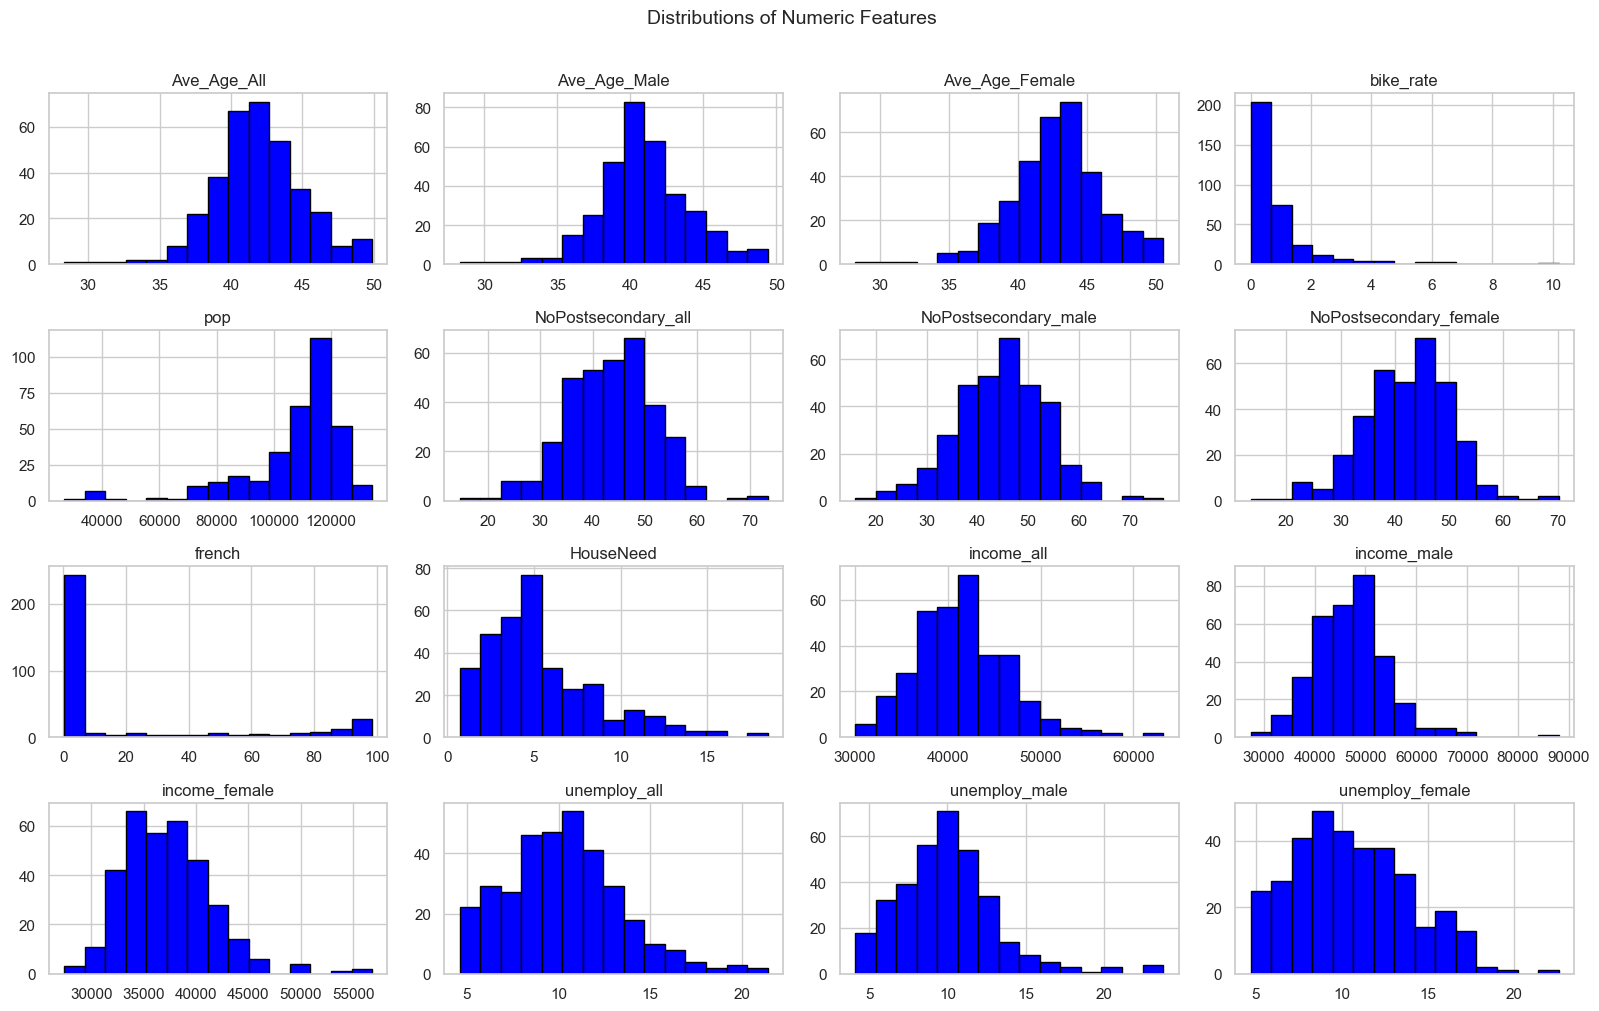

In [15]:
df[numeric_columns].hist(bins=15, figsize=(16, 10),
                         color="blue", edgecolor="black")
plt.suptitle("Distributions of Numeric Features", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

Most features are roughly bell-shaped.

`french` is heavily right-skewed

`pop` is super left-skewed

we need to standardize features before fitting svms

---
## 5--Correlation Matrix

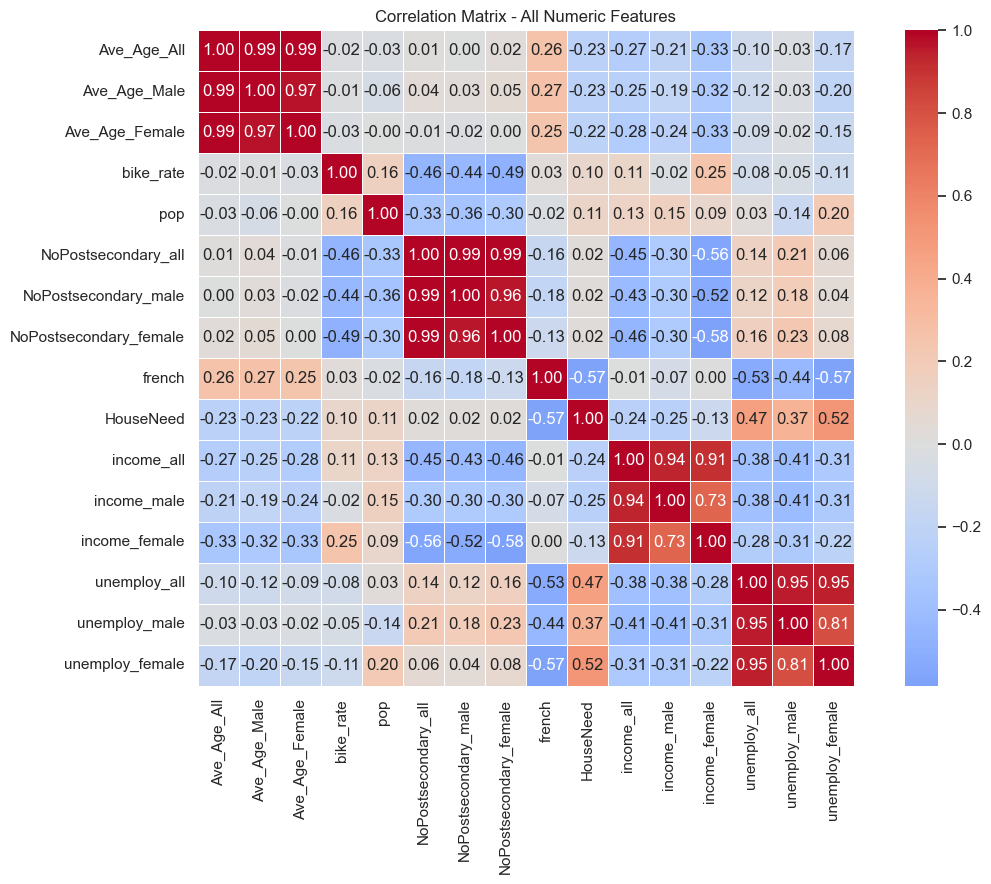

In [18]:
plt.figure(figsize=(12, 9))
corr = df[numeric_columns].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Correlation Matrix - All Numeric Features")
plt.tight_layout()
plt.show()

---
## 6 -- Multicollinearity

from above, many features come in male / female / all triples are correlated.

In [20]:
high_corr = []
for i in range(len(numeric_columns)):
    for j in range(i + 1, len(numeric_columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((numeric_columns[i], numeric_columns[j], round(r, 3)))

hc_df = pd.DataFrame(high_corr, columns=["Feature i", "Feature j", "r"])
display(hc_df)

,Feature i,Feature j,r
0,Ave_Age_All,Ave_Age_Male,0.992
1,Ave_Age_All,Ave_Age_Female,0.994
2,Ave_Age_Male,Ave_Age_Female,0.974
3,NoPostsecondary_all,NoPostsecondary_male,0.991
4,NoPostsecondary_all,NoPostsecondary_female,0.990
5,NoPostsecondary_male,NoPostsecondary_female,0.963
6,income_all,income_male,0.943
7,income_all,income_female,0.913
8,unemploy_all,unemploy_male,0.954
9,unemploy_all,unemploy_female,0.950


Keeping these triples adds noise without new information, so I collapsed each triple to the `_all` version in the preprocessing file.

**Exception:** `income_male` and `income_female` have opposite correlations with the target (male income is neg correlated with being Liberal, female income is pos ) so we're onto something here


**Dropped**: `Ave_Age_Male`, `Ave_Age_Female`, `NoPostsecondary_male`, `NoPostsecondary_female`, `unemploy_male`, `unemploy_female`


In [21]:
reduced_features = FEATURE_COLUMNS
print(f"Reduced feature count: {len(reduced_features)}")
print(reduced_features)

Reduced feature count: 10
['Ave_Age_All', 'bike_rate', 'pop', 'NoPostsecondary_all', 'french', 'HouseNeed', 'income_all', 'income_male', 'income_female', 'unemploy_all']


---
## 7 - Feature Correlation with the Target



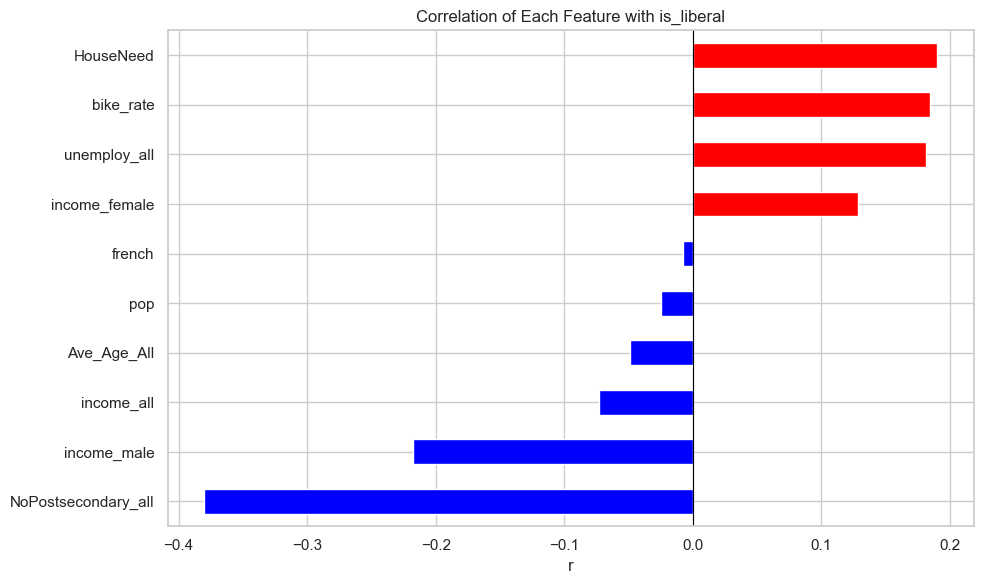

NoPostsecondary_all   -0.380
income_male           -0.217
income_all            -0.073
Ave_Age_All           -0.049
pop                   -0.025
french                -0.008
income_female          0.128
unemploy_all           0.181
bike_rate              0.184
HouseNeed              0.190
Name: is_liberal, dtype: float64


In [26]:
target_corr = (
    df[reduced_features + ["is_liberal"]]
    .corr()["is_liberal"]
    .drop("is_liberal")
    .sort_values()
)

plt.figure(figsize=(10, 6))
colors = ["red" if v > 0 else "blue" for v in target_corr.values]
target_corr.plot.barh(color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of Each Feature with is_liberal")
plt.xlabel("r")
plt.tight_layout()
plt.show()

print(target_corr.round(3))

No single feature dominates $\rightarrow$ **nonlinear kernel** to capture interactions that a linear SVM can't.

---
## 8 -- Feature Averages by Party

In [28]:
party_means = (
    df.groupby("Political Affiliation")[reduced_features]
      .mean()
      .round(2)
      .sort_index()
)
display(party_means)

,Ave_Age_All,bike_rate,pop,NoPostsecondary_all,french,HouseNeed,income_all,income_male,income_female,unemploy_all
Political Affiliation,,,,,,,,,,
Bloc Québécois,43.91,0.69,105364.55,44.28,92.04,1.90,41072.73,46581.82,36127.27,6.51
Conservative,41.83,0.60,108875.92,47.17,9.49,5.10,42190.14,49361.27,36770.42,10.20
Green Party,48.60,3.50,122150.00,37.10,1.20,5.10,44400.00,50400.00,40000.00,6.30
Liberal,41.75,1.32,107361.62,40.29,19.57,6.07,41176.47,45450.00,37807.06,10.88
NDP,39.97,4.34,102307.14,44.56,12.00,8.39,38800.00,40628.57,37400.00,11.01


Note:

Bloc Québécois have extremely high `french` (≈93%)

Conservative have the highest `NoPostsecondary_all`

NDP have the highest `bike_rate`

But nothing really stands out to me; their averages are noisy. No single feature classifies well on its own, and we probably need a combination

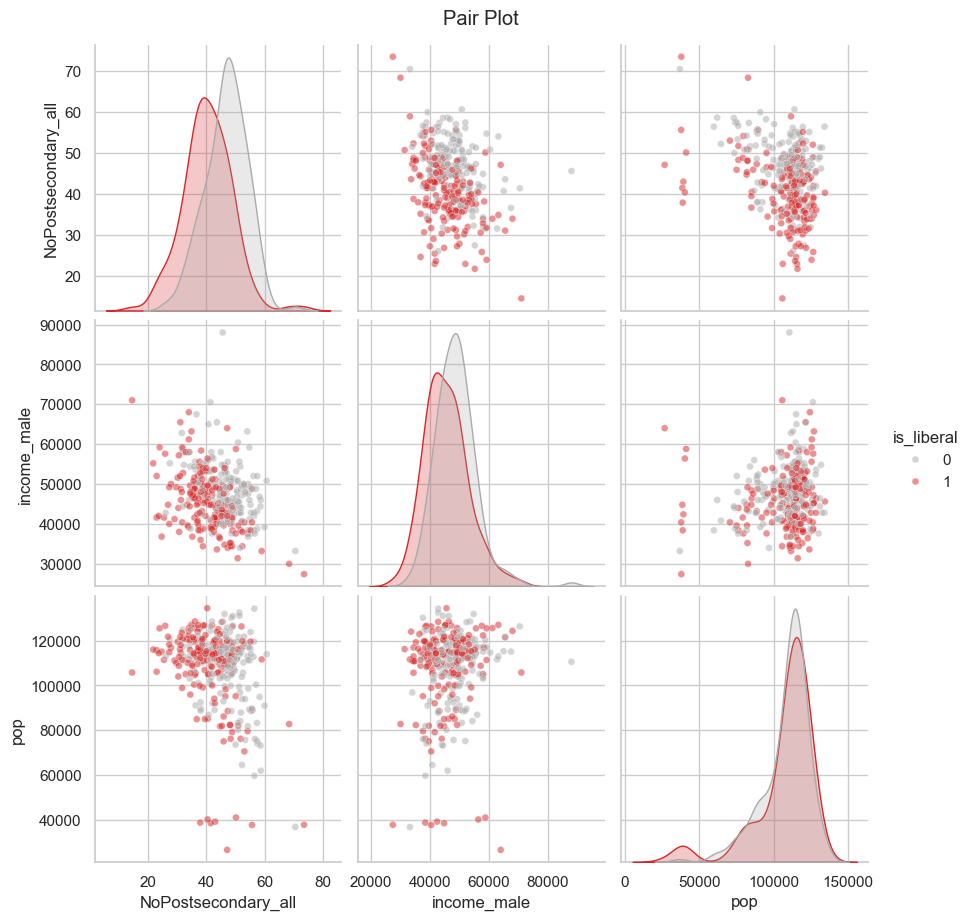

In [31]:
top3 = ["NoPostsecondary_all", "income_male", "pop"] # visually these were the top 3 features

g = sns.pairplot(
    df, vars=top3, hue="is_liberal",
    palette={0: "#aaaaaa", 1: "#d62728"},
    plot_kws={"alpha": 0.5, "s": 25},
    height=3,
)
g.fig.suptitle("Pair Plot", y=1.02)
plt.show()

I am 99% confident that we need to train nonlinear kernels (rbf, polynomial)

## Kernels to explore

1. Linear as a baseline  $K(x, x') = x \cdot x'$
2. RBF $K(x, x') = \exp(-\gamma \|x - x'\|^2)$
3. Polynomial $K(x, x') = (\gamma\, x \cdot x' + b)^d$; degree $d$, $b$ are tunable hyperparameters
4. Sigmoid $K(x, x') = \tanh(\gamma\, x \cdot x' + b)$

### Cross-validation
- 5-fold CV (we don't have many n) for hyperparameter tuning ($\lambda$, $\gamma$, polynomial degree $d$, etc.).
- Within each fold: standardize the training split (zero mean, unit variance) and apply the same transform to the held-out fold.
- reported accuracy: mean ± std across folds.

### Optimization algorithms to compare
**at least 3 algorithms**

1. **Adam** $\rightarrow$ basically default for ML
2. **Mini-batch SGD** $\rightarrow$ same family as Robbins Monro but more stable (less noisy and easier to tune) thanks to mini batches
3. Simultaneous perturbation stochastic approximation **SPSA** $\rightarrow$ gradient-free, stochastic -> useful as a comparison method
